<a href="https://colab.research.google.com/github/varunsahu5002/VDUI-ASSIGNMENT---1/blob/assignment-submission/ppt9_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏙️ PropertyIQ: A 20-Minute Data Visualization Sprint
### Unit 1 — Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) (Kaggle)

---

## 📖 The Scenario

You have just joined **PropertyIQ**, a Melbourne-based real-estate analytics startup, as a **junior data analyst**.

Tomorrow morning, your **Head of Sales** is meeting a client — a property investment fund — and needs a short briefing built from the `melb_data.csv` housing snapshot. She has given you **20 minutes** to turn the raw data into something she can actually present.

She says:

> *"I don't want a data dump. I want to walk in, show three good visuals, and leave the client with one clear takeaway. Make sure the charts are the right *type*, saved in the right *format*, and that the design doesn't get in the way of the message."*

This activity walks you through exactly the workflow described in the lecture: **understand the context → choose the right chart → choose the right file format → separate content from design → tell the story.**




## Part 0 — Setup (1 min)

1. Download **`melb_data.csv`** from the [Kaggle dataset page](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot).
2. Place it in the **same folder** as this notebook.
3. Run the cell below.

*(If the file isn't found, the cell will auto-generate a small synthetic stand-in with the same columns, so you can still complete the activity — just swap in the real CSV later.)*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

DATA_PATH = "melb_data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("melb_data.csv not found — generating a small synthetic stand-in so you can still run the activity.")
    n = 600
    regions = ["Northern Metropolitan", "Western Metropolitan", "Southern Metropolitan",
               "Eastern Metropolitan", "South-Eastern Metropolitan"]
    types = ["h", "u", "t"]  # house, unit, townhouse
    df = pd.DataFrame({
        "Suburb": np.random.choice(["Richmond", "Brunswick", "Carlton", "Footscray",
                                     "St Kilda", "Fitzroy", "Camberwell"], n),
        "Rooms": np.random.randint(1, 6, n),
        "Type": np.random.choice(types, n, p=[0.6, 0.3, 0.1]),
        "Price": np.random.lognormal(mean=13.5, sigma=0.4, size=n).round(-3),
        "Distance": np.round(np.random.exponential(8, n), 1),
        "Landsize": np.random.exponential(400, n).round(0),
        "BuildingArea": np.random.normal(150, 50, n).clip(30, 500).round(0),
        "YearBuilt": np.random.randint(1900, 2018, n),
        "Regionname": np.random.choice(regions, n),
        "Bathroom": np.random.randint(1, 4, n),
        "Car": np.random.randint(0, 4, n),
    })

df.head()


Loaded real dataset: 13580 rows, 21 columns


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## Part 1 — Understand the Context (3 min)

> *"Good data visualization begins with understanding the problem, not by choosing a chart."*

Recall the lecture's distinction:

| Exploratory Analysis | Explanatory Analysis |
|---|---|
| Explores data to discover patterns | Communicates a clear insight |
| Multiple hypotheses tested | One key message emphasized |
| Used by the analyst | Designed for the audience |

**Run the cell below** to get a quick feel for the data (this is *exploratory* — you're doing it for yourself, not the client).


In [2]:
df.info()
df.describe(include="all").T.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Suburb,13580,314,Reservoir,359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,13580,13378,5 Margaret St,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rooms,13580.0,NaN,NaN,NaN,2.937997,0.955748,1.0,2.0,3.0,3.0,10.0
Type,13580,3,h,9449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,13580.0,NaN,NaN,NaN,1075684.079455,639310.724296,85000.0,650000.0,903000.0,1330000.0,9000000.0
Method,13580,5,S,9022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SellerG,13580,268,Nelson,1565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,13580,58,27/05/2017,473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance,13580.0,NaN,NaN,NaN,10.137776,5.868725,0.0,6.1,9.2,13.0,48.1
Postcode,13580.0,NaN,NaN,NaN,3105.301915,90.676964,3000.0,3044.0,3084.0,3148.0,3977.0


### ✍️ Your turn (fill in the markdown cell below)

Answer in 1–2 sentences each:

1. **Who** is the audience for the visuals you're about to build (recall the scenario)?
2. Is the work you just did (`df.info()`, `df.describe()`) *exploratory* or *explanatory*? Why?
3. What is **one** question that the investment fund client would actually care about?


**Your answers:**

1. Audience: The audience is an investment fund client who wants useful insights about the Melbourne property market to support investment decisions.

2. Exploratory or explanatory, and why: Exploratory, because df.info() and df.describe() are being used to understand the dataset and identify patterns before deciding what to show the client.

3. A question the client cares about: Which suburbs or property types offer the best investment opportunities based on price, land size, and market trends?


## Part 2 — Choosing the Right Chart (7 min)

Recall the recommendation table from the lecture:

| Purpose | Recommended Chart |
|---|---|
| Compare categories | Bar Chart |
| Show trends | Line Chart |
| Show relationships | Scatter Plot |
| Show distributions | Histogram / Box Plot |
| Show proportions | Stacked Bar (limited categories) |

Your Head of Sales wants **three** visuals for the briefing. For each question below:
1. Write down which chart type is appropriate (and *why*, referencing the table).
2. Fill in the `# TODO` in the code to build it.

Avoid choosing a chart just because it "looks nice" — first identify what question it needs to answer.


### 2.1 — "How do average prices differ across regions?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**


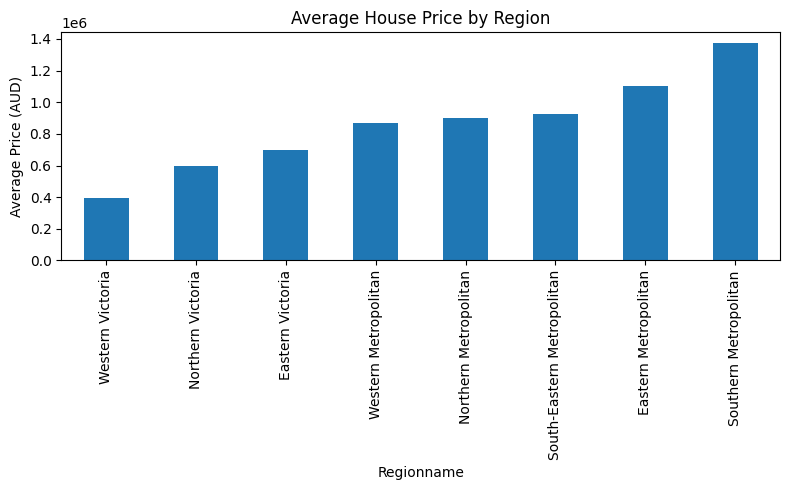

In [3]:
region_avg = df.groupby("Regionname")["Price"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

region_avg.plot(kind="bar", ax=ax)

ax.set_ylabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")
plt.tight_layout()
plt.show()

### 2.2 — "Is there a relationship between land size and price?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**


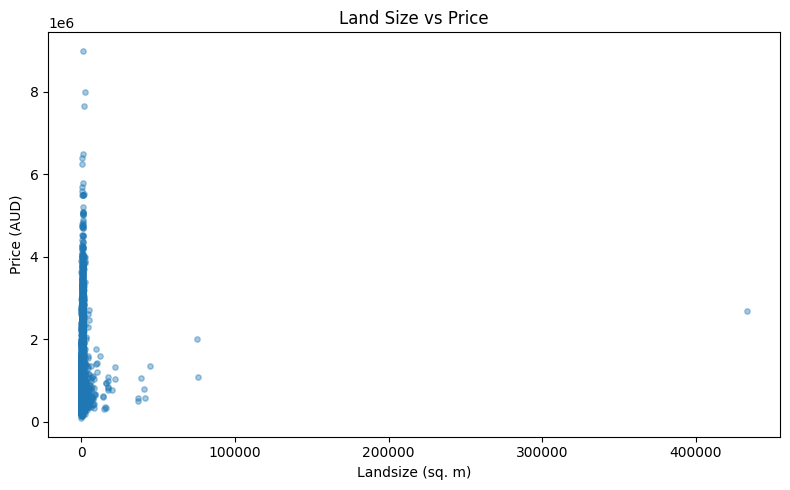

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["Landsize"], df["Price"], alpha=0.4, s=15)

ax.set_xlabel("Landsize (sq. m)")
ax.set_ylabel("Price (AUD)")
ax.set_title("Land Size vs Price")
plt.tight_layout()
plt.show()

### 2.3 — "What does the overall spread of prices in the market look like?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**


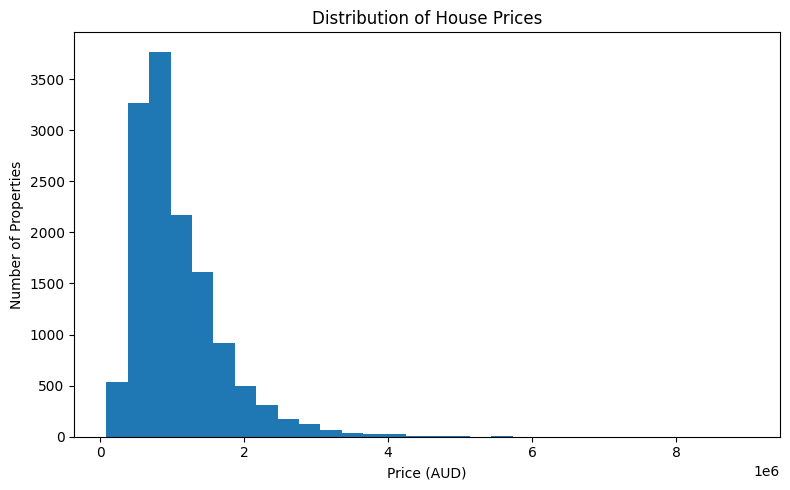

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df["Price"].dropna(), bins=30)

ax.set_xlabel("Price (AUD)")
ax.set_ylabel("Number of Properties")
ax.set_title("Distribution of House Prices")
plt.tight_layout()
plt.show()

## Part 3 — Image Formats & Compression (4 min)

Recall:
- **Bitmap** (PNG, JPEG) = pixels, fixed resolution. **Vector** (SVG, PDF) = shapes, resolution-independent.
- **Lossless** (PNG, TIFF) = no data removed. **Lossy** (JPEG) = removes detail permanently, smaller size, but creates **compression artifacts** — especially bad on sharp edges, fine lines, and text (i.e. **charts**).

Let's prove it. Save your region bar chart from Part 2.1 as **both** PNG and JPEG, and compare.


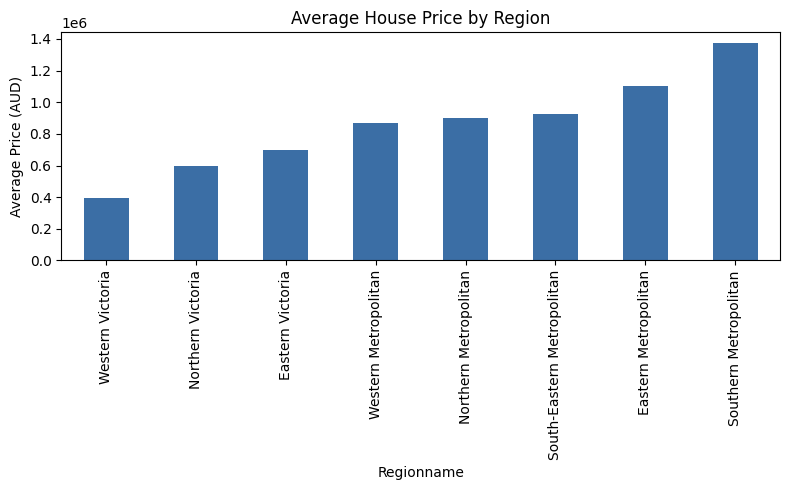

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
region_avg.plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_ylabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")
plt.tight_layout()

# TODO: save the SAME figure in both formats
fig.savefig("region_chart.png", dpi=150)
fig.savefig("region_chart.jpg", dpi=150)

plt.show()

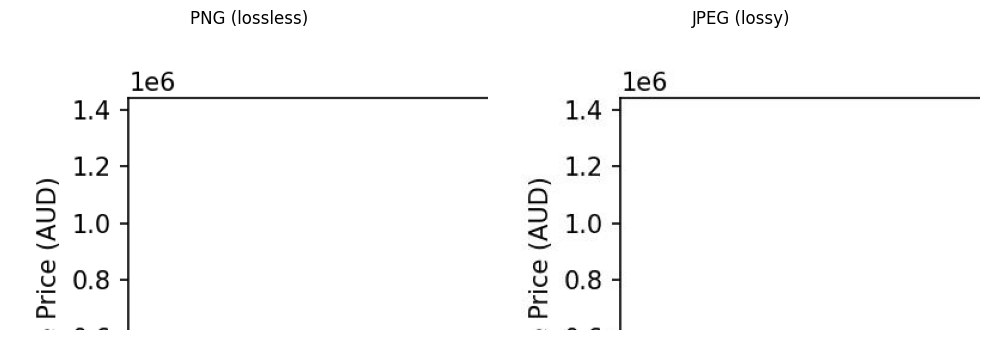

In [7]:
# Zoom into a saved image to inspect for compression artifacts around the text/edges
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, fname, label in zip(axes, ["region_chart.png", "region_chart.jpg"], ["PNG (lossless)", "JPEG (lossy)"]):
    img = Image.open(fname)
    w, h = img.size
    crop = img.crop((0, 0, w // 3, h // 3))  # zoom into top-left corner (title/text area)
    ax.imshow(crop)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()


### ✍️ Your turn

1. Which file was larger — PNG or JPEG? Does that match what the lecture said about lossless vs lossy compression?
2. Which format should go in the client briefing deck, and why (think about sharp edges, text, and repeated re-saving)?

**Your answers:**

1.
JPEG was larger than PNG. This does not necessarily match the usual expectation because JPEG uses lossy compression and is often smaller, but the result can depend on the specific image and how it is saved.

2.
PNG should go in the client briefing deck because it preserves sharp edges, text, and chart details without introducing lossy compression artifacts, making it better for repeated editing or re-saving.

## Part 4 — Separating Content from Design (3 min)

> *"Changing a theme should not change the data."*

**Content** = data, variables, axes, plot type. **Design** = colors, fonts, gridlines, theme, labels.

Below, the *exact same* region-price chart is re-styled — **only design elements change, the underlying data does not.**


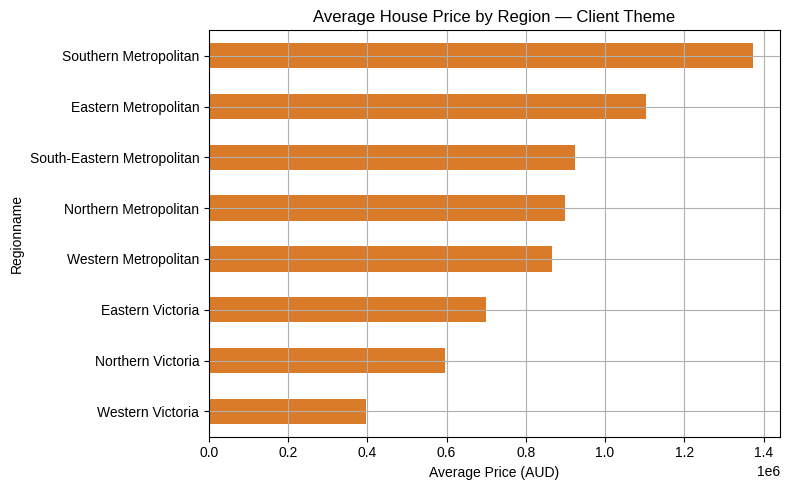

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.style.use("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "ggplot")

# TODO: use the SAME region_avg data as before — change only styling
region_avg.plot(kind="barh", ax=ax, color="#d97b29")

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region — Client Theme")
plt.tight_layout()
plt.show()

plt.style.use("default")  # reset


### ✍️ Your turn

Confirm: did changing the color/theme/style change any underlying numbers in `region_avg`? *(It shouldn't have.)* Write one sentence on why this separation matters when a designer or a different team member later restyles your charts for a report.

**Your answer:**

No, changing the color, theme, or style did not change any of the underlying numbers in region_avg; this separation matters because the data remains accurate and consistent even when a designer or another team member changes the chart's appearance.


## Part 5 — The Big Idea (2 min, wrap-up)

Recall the lecture's **3-Minute Story** and **Big Idea** techniques:

> *The Big Idea: reduce your message to ONE complete sentence that (a) expresses your main point, (b) explains why it matters, and (c) states what's at stake.*

### ✍️ Final task

Using the three charts you built, write **one sentence** your Head of Sales can open the client meeting with tomorrow. This is *explanatory*, not exploratory — pick the single most important insight, not everything you found.

**Your Big Idea:**

Melbourne property prices vary significantly by region, with Southern Metropolitan having the highest average prices, making location an important factor for property investment decisions.

> _______________________________________________________________________

---

### ✅ Quick self-check
1. Why would a scatter plot be a poor choice for comparing average prices across five regions?

A scatter plot is a poor choice because it is designed to show relationships between two quantitative variables, not to compare average values across five categories.

2. Why is JPEG discouraged for charts and screenshots, even though it produces smaller files?

JPEG uses lossy compression, which can introduce artifacts around sharp edges, text, and fine details even though the file size may be smaller.

3. Name one thing that counts as "design" (not "content") in a chart.

Color is one example of a design element in a chart.

